In [205]:
#23 08
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt


In [206]:

df=pd.read_csv("../docs/newDocs/csv/Airlines.csv",na_values=['/','-',' ','','NA','null'])
df = df.sample(n=10000, random_state=42)


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 442150 to 390100
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           10000 non-null  int64 
 1   Airline      10000 non-null  object
 2   Flight       10000 non-null  int64 
 3   AirportFrom  10000 non-null  object
 4   AirportTo    10000 non-null  object
 5   DayOfWeek    10000 non-null  int64 
 6   Time         10000 non-null  int64 
 7   Length       10000 non-null  int64 
 8   Delay        10000 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 781.2+ KB


In [208]:
df.isna().sum()#vidimo da nemamo NA vrednosti

id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

In [209]:

df.drop(columns="id",inplace=True)#dropujemo kolonu id jer nema doprinosa modelu previse razlicitih vrednosti nista nam ne znaci

In [210]:
df['IsDelayed']=np.where(df['Delay']==1,1,0)

In [211]:
df['IsDelayed'].value_counts()

IsDelayed
0    5549
1    4451
Name: count, dtype: int64

In [212]:
df.drop(columns="Delay",inplace=True)#dropujemo kolonu jer nam vise ne treba

In [213]:
df['Airline'].value_counts() #oznaka aerodroma ima previse razlicith vrednosti i nije nam potrebna u modelu

Airline
WN    1707
DL    1076
OO     988
AA     884
MQ     684
US     644
XE     577
EV     509
UA     499
CO     398
FL     397
9E     392
B6     326
OH     260
YV     248
AS     195
HA     109
F9     107
Name: count, dtype: int64

In [214]:
df.drop(columns="Airline",inplace=True)

In [215]:
df['AirportFrom'].value_counts()# AirportFrom kolona ima previse razlicith vrednosti i nije nam potrebna u modelu

AirportFrom
ATL    587
ORD    472
DFW    412
DEN    398
IAH    307
      ... 
HTS      1
SPS      1
ACT      1
LMT      1
GRK      1
Name: count, Length: 256, dtype: int64

In [216]:
df.drop(columns="AirportFrom",inplace=True)

In [217]:
df.drop(columns="AirportTo",inplace=True) #isto kao airportFrom..

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 442150 to 390100
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Flight     10000 non-null  int64
 1   DayOfWeek  10000 non-null  int64
 2   Time       10000 non-null  int64
 3   Length     10000 non-null  int64
 4   IsDelayed  10000 non-null  int64
dtypes: int64(5)
memory usage: 468.8 KB


In [219]:
df=df[df['Length']<=400]

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9979 entries, 442150 to 390100
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Flight     9979 non-null   int64
 1   DayOfWeek  9979 non-null   int64
 2   Time       9979 non-null   int64
 3   Length     9979 non-null   int64
 4   IsDelayed  9979 non-null   int64
dtypes: int64(5)
memory usage: 467.8 KB


In [221]:
df['Flight'].value_counts()#oznaka leta takodje nam nista ne znaci ima previse razlicith vrednosti ...


Flight
491     12
610     11
371     10
9       10
36      10
        ..
3949     1
7268     1
6323     1
3339     1
376      1
Name: count, Length: 4478, dtype: int64

In [222]:
df.drop(columns="Flight",inplace=True)

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9979 entries, 442150 to 390100
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DayOfWeek  9979 non-null   int64
 1   Time       9979 non-null   int64
 2   Length     9979 non-null   int64
 3   IsDelayed  9979 non-null   int64
dtypes: int64(4)
memory usage: 389.8 KB


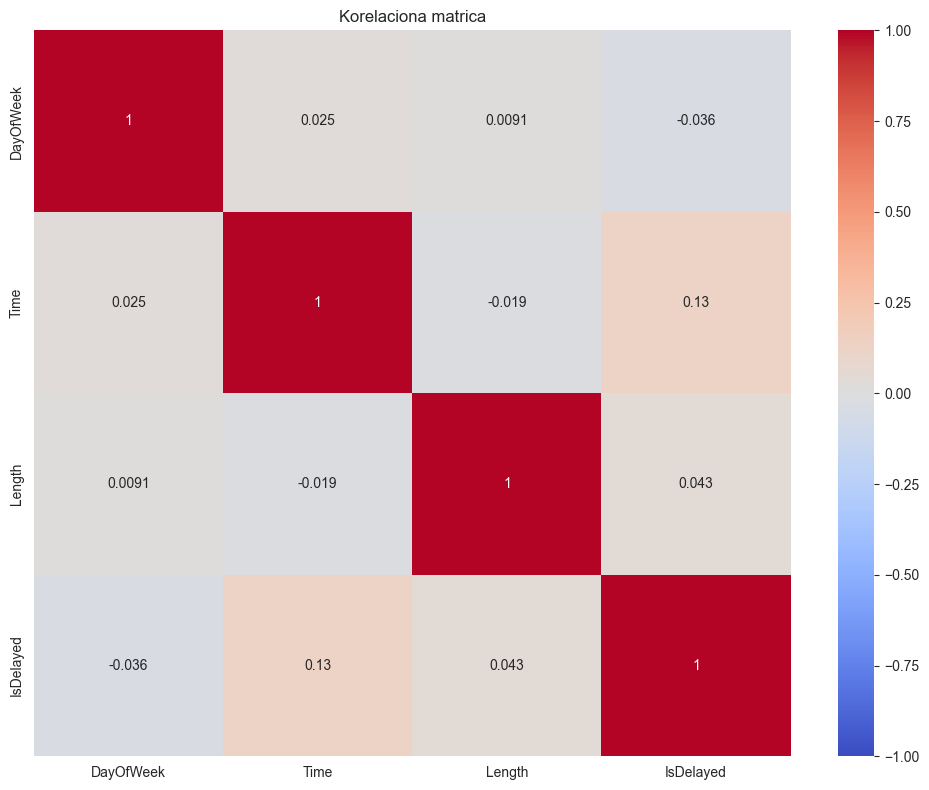

In [224]:
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [225]:
#na osnovu korelacione matrice vidimo da nijedna varijabla nije previse korelisana sa ostalima i mozemo sve da ih ostavimo u modelu ...

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9979 entries, 442150 to 390100
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   DayOfWeek  9979 non-null   int64
 1   Time       9979 non-null   int64
 2   Length     9979 non-null   int64
 3   IsDelayed  9979 non-null   int64
dtypes: int64(4)
memory usage: 389.8 KB


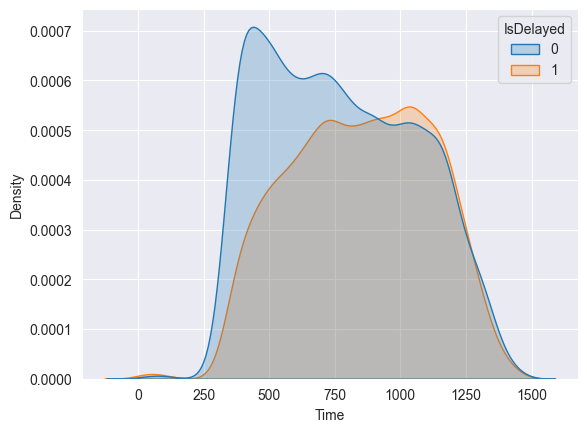

In [227]:
#sve kolone osim targeta IsDelayed su prediktori ...
#pogledacemo grafike kolone
plt.figure()
sb.kdeplot(x=df['Time'],hue=df['IsDelayed'],fill=True) # vidimo na osnovu grafa da je time bitna varijabla za predvidjanje IsDelayed zato je ostavljamo i prolazi ovaj test jer se grafici seku i nemaju istu raspodelu
plt.show()

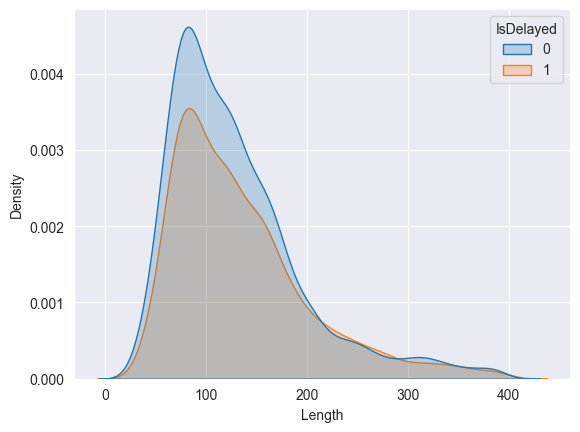

In [228]:
plt.figure()
sb.kdeplot(x=df['Length'],hue=df['IsDelayed'],fill=True) # vidimo na osnovu grafa da je raspodela skoro ista ali da ima malih secenja i razlika u duzini oko 300 zato ostavljamo ...
plt.show()

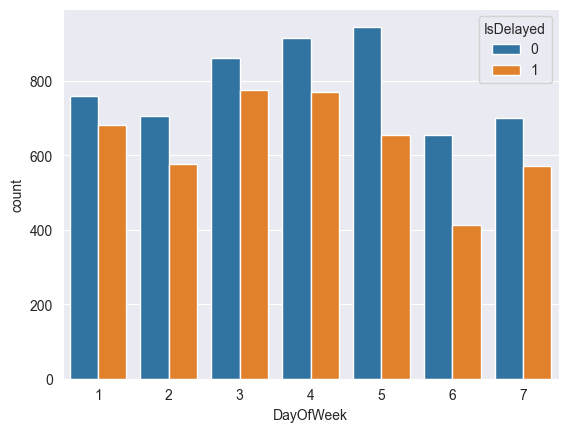

In [229]:
plt.figure()
sb.countplot(x=df['DayOfWeek'],hue=df['IsDelayed'],fill=True) # vidimo na osnovu grafa da je raspodela razlicita zato i ovo ostavljamo kao bitan prediktor..
plt.show()

In [230]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X=df.drop(columns='IsDelayed')
y=df['IsDelayed']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y)

In [231]:
from sklearn.model_selection import train_test_split, StratifiedKFold,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree

param_grid={'ccp_alpha':np.arange(0.00,0.05,0.0025)}

cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
clf = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42,),param_grid=param_grid,scoring='balanced_accuracy',
        cv=cv,
        verbose=1,n_jobs=-1)

clf.fit(X_train, y_train)
best=clf.best_params_

Fitting 10 folds for each of 20 candidates, totalling 200 fits


In [232]:
ccp=best
ccp

{'ccp_alpha': np.float64(0.0)}

[Text(0.43005419436782344, 0.9871794871794872, 'x[1] <= 615.5\ngini = 0.494\nsamples = 7983\nvalue = [4430, 3553]'),
 Text(0.10005607157744599, 0.9615384615384616, 'x[1] <= 430.5\ngini = 0.446\nsamples = 2385\nvalue = [1586, 799]'),
 Text(0.2650551329726347, 0.9743589743589745, 'True  '),
 Text(0.03238317150258739, 0.9358974358974359, 'x[1] <= 72.5\ngini = 0.381\nsamples = 839\nvalue = [624.0, 215.0]'),
 Text(0.0063592199187996025, 0.9102564102564102, 'x[0] <= 2.5\ngini = 0.278\nsamples = 12\nvalue = [2, 10]'),
 Text(0.005953851318398034, 0.8846153846153846, 'x[1] <= 37.5\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.005548482717996466, 0.8589743589743589, 'x[2] <= 191.5\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.005143114117594897, 0.8333333333333334, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.005953851318398034, 0.8333333333333334, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.0063592199187996025, 0.8589743589743589, 'gini = 0.0\nsamples = 1\nvalue = [

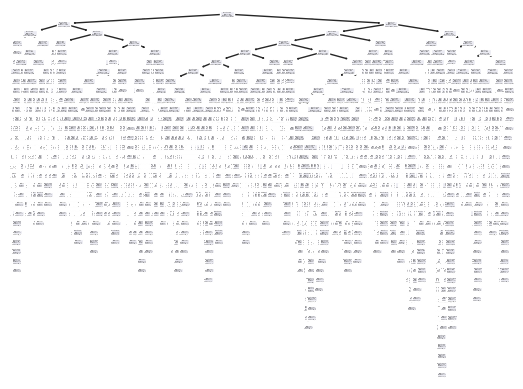

In [233]:
clf = DecisionTreeClassifier(random_state=0,ccp_alpha=0)
clf = clf.fit(X_train, y_train)
plot_tree(clf)

In [234]:
from sklearn.metrics import confusion_matrix
y_pred=clf.predict(X_test)


In [235]:
tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel().tolist()

In [236]:
konfuzija=confusion_matrix(y_test,y_pred)
konfuzija

array([[618, 490],
       [469, 419]])

In [237]:
print("true negative ", tn)
print("false positive ", fp)
print("false negative", fn)
print("true positive", tp)

true negative  618
false positive  490
false negative 469
true positive 419


In [241]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.57      0.56      0.56      1108
           1       0.46      0.47      0.47       888

    accuracy                           0.52      1996
   macro avg       0.51      0.51      0.51      1996
weighted avg       0.52      0.52      0.52      1996

